## Ahmed Adnan, Eugen Erb, Nicolas Huhle

### a) What is an edge and how is it visible in an image and its derivative?
An edge is a place in an image where the intensity changes sharply over a small area and in a specific direction. It appears as a boundary between different regions. Technically, this is where the first derivative of the intensity function is large (the rate of change is large) — it helps to detect how steeply brightness changes at that point​ <br>
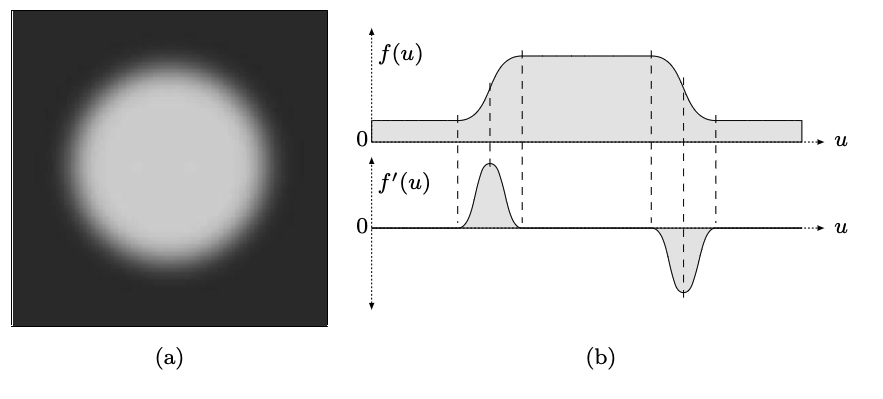

### b) What are the partial derivatives of an image? What do they tell us?
Partial derivatives of an image are the rate of change of pixel intensity along the horizontal (∂I/∂x) and vertical (∂I/∂y) directions. They show how fast and in which direction the intensity is changing, which helps identify edges and their orientations. <br>
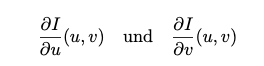

### c) What is the gradient vector of an image?
The gradient vector is a 2D vector formed from the partial derivatives in x and y directions:

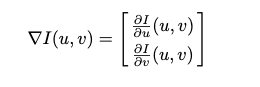 <br>
It points in the direction of the maximum rate of intensity change, and its length tells us how strong the edge is at that point​

### d) How can the edge strength be calculated?
The edge strength is the magnitude of the gradient vector: <br>
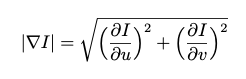 <br>
This gives a scalar value representing how strong the edge is at pixel (u,v)

### e) How can the local edge direction be calculated?
The local edge direction is calculated using the arctangent of the vertical and horizontal gradients: <br>
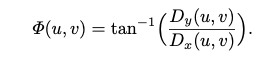 <br>
This angle tells us the orientation of the edge at a specific point​

## 2. Define Sobel filter kernels
below is the code from sobel.py

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import time

def rgb_2_gray(img, mode='lut'):
    if mode == 'lut':
        return np.round(img[:,:,0] * 0.2126 + img[:,:,1] * 0.7152 + img[:,:,2] * 0.0722)
    else:
        return np.round(img[:,:,0] * 0.2126 + img[:,:,1] * 0.587 + img[:,:,2] * 0.114)

##### Sobel filtering function (implementation using loops)
applies sobel filter to an image using nested loops in Python. It computes the convolution manually, normalizes the result to the range 0–255, and returns the filtered image as an 8-bit array.

In [16]:
def sobel(img, filter):
    height, width = img.shape
    filter_size = filter.shape[0]
    K = filter_size // 2  # filter "radius"

    # Prepare output image (exclude border based on filter size)
    filtered_img = np.zeros((height - 2*K, width - 2*K))

    # Apply filter using nested loops
    for y in range(K, height - K):             # Skip top/bottom K rows
        for x in range(K, width - K):          # Skip left/right K columns
            value = 0
            for j in range(-K, K + 1):         # Loop vertically over filter
                for i in range(-K, K + 1):     # Loop horizontally over filter
                    value += img[y + j, x + i] * filter[j + K, i + K]  # apply filter
            filtered_img[y - K, x - K] = value  # write to output (adjust for padding)

    # result 0–255 for display
    filtered_img = np.abs(filtered_img)
    filtered_img = (filtered_img / np.max(filtered_img)) * 255
    return filtered_img.astype(np.uint8)


##### Define Sobel filters


In [17]:
filter_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

filter_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

##### calculate the duration of calculation for horz and ver.

In [18]:
img = io.imread("lena.jpg")
gray = rgb_2_gray(img)

# Sobel X (horizontal edges)
start = time.time()
sobel_x_result = sobel(gray, filter_x)
end = time.time()
print("X-direction duration in milliseconds:", (end - start) * 1000)

# Sobel Y (vertical edges)
start = time.time()
sobel_y_result = sobel(gray, filter_y)
end = time.time()
print("Y-direction duration in milliseconds:", (end - start) * 1000)

X-direction duration in milliseconds: 1814.2380714416504
Y-direction duration in milliseconds: 1421.2539196014404


##### Show both results


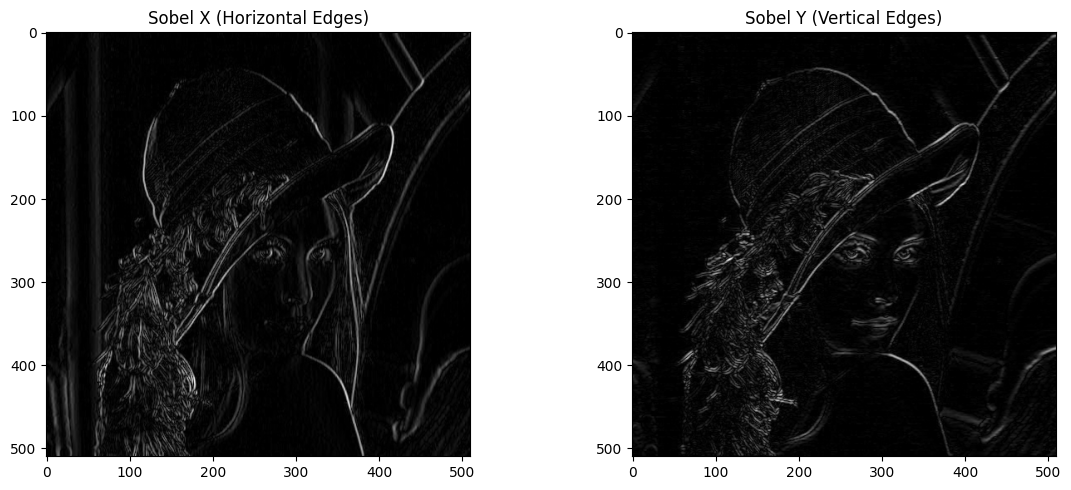

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Sobel X (Horizontal Edges)")
plt.imshow(sobel_x_result, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Sobel Y (Vertical Edges)")
plt.imshow(sobel_y_result, cmap='gray')

plt.tight_layout()
plt.show()


#### To compare the performance of having for loops with using np.sum function and multiplication with the previous sobel implementation

In [20]:
def sobel2(img, filt):
    height, width = img.shape
    filter_size = filt.shape[0]
    K = filter_size // 2

    out_img = np.zeros((height - 2 * K, width - 2 * K))

    # loop over valid center pixels
    for y in range(K, height - K):
        for x in range(K, width - K):
            region = img[y - K : y + K + 1, x - K : x + K + 1]
            value = np.sum(region * filt)
            
            #result (shifted due to K)
            out_img[y - K, x - K] = value

    out_img = np.abs(out_img)
    out_img = (out_img / np.max(out_img)) * 255

    return out_img.astype(np.uint8)


In [21]:
# Sobel2 X (horizontal edges)
start = time.time()
sobel2_x_result = sobel2(gray, filter_x)
end = time.time()
print("X-direction duration in milliseconds:", (end - start) * 1000)

# Sobel2 Y (vertical edges)
start = time.time()
sobel2_y_result = sobel2(gray, filter_y)
end = time.time()
print("Y-direction duration in milliseconds:", (end - start) * 1000)

X-direction duration in milliseconds: 2311.962127685547
Y-direction duration in milliseconds: 2278.1429290771484


##### did not notice a huge difference, most of the time having 4 loops was even faster

### Compute Gradient Magnitude
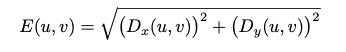 <br>
This function calculates the gradient magnitude from the horizontal and vertical Sobel results using the Euclidean norm

In [22]:
def gradient_magnitude(Gx, Gy):
    """
    Computes the gradient magnitude image from Gx and Gy.
    
    Parameters:
        Gx (2D np.array): Sobel result in X direction
        Gy (2D np.array): Sobel result in Y direction

    Returns:
        Magnitude image (2D np.uint8)
    """
    # Convert to float for precision
    Gx = Gx.astype(np.float32)
    Gy = Gy.astype(np.float32)

    # gradient magnitude
    magnitude = np.sqrt(Gx**2 + Gy**2)

    magnitude = (magnitude / np.max(magnitude)) * 255

    return magnitude.astype(np.uint8)

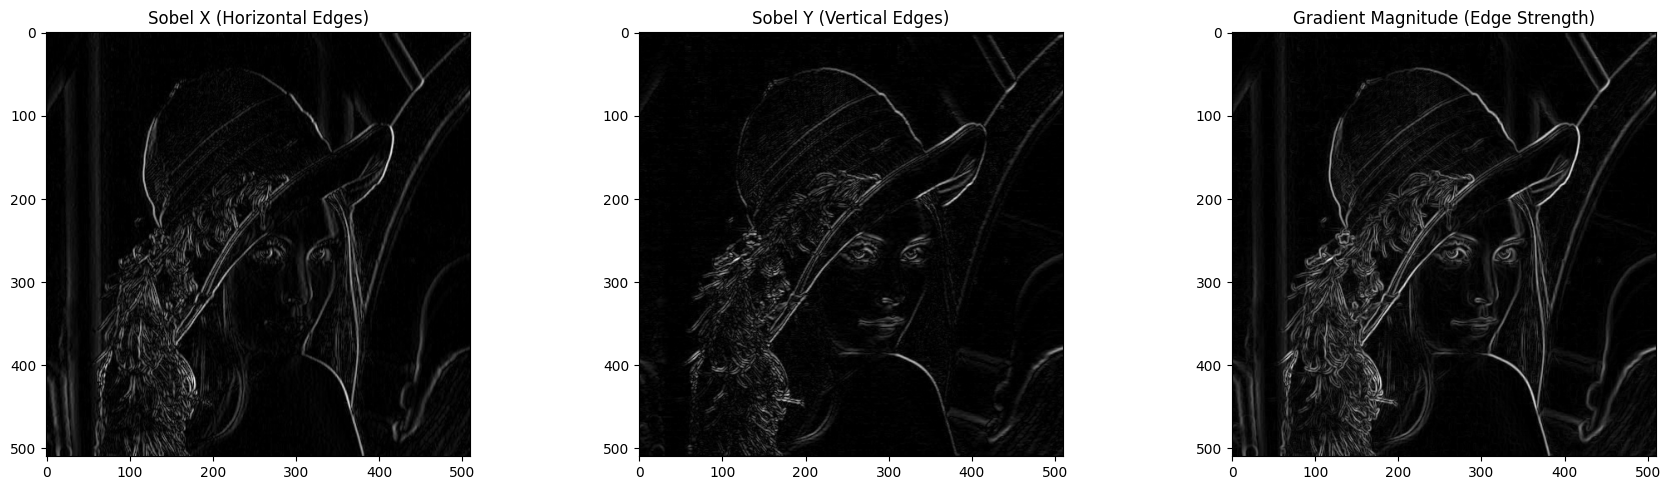

In [23]:
Gx = sobel(gray, filter_x)
Gy = sobel(gray, filter_y)
Gmag = gradient_magnitude(Gx, Gy)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.title("Sobel X (Horizontal Edges)")
plt.imshow(sobel_x_result, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Sobel Y (Vertical Edges)")
plt.imshow(sobel_y_result, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Gradient Magnitude (Edge Strength)")
plt.imshow(Gmag, cmap='gray')

plt.tight_layout()
plt.show()

### from the c++ file:

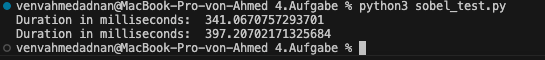

To better understand the impact of language and implementation choice on performance, we measured the execution time of the Sobel filter implemented in three ways: <br>
| Version                | Time (ms) | Description                                                                 |
| ---------------------- | --------- | --------------------------------------------------------------------------- |
| Python (manual loops)  | \~1500 ms | Plain Python with nested `for` loops (slowest due to interpreted execution) |
| Python (with `np.sum`) | \~2200 ms | Used `np.sum` inside the loop, but still involved many slow iterations      |
| C++ via pybind11       | \~370 ms  | Compiled C++ code wrapped via `pybind11` (much faster)                      |
<br> 
When performance is critical (e.g., image processing, real-time systems), using C++ and exposing the logic to Python via bindings like pybind11 gives significant speedups — in this case, a ~4× improvement over plain Python.



### not in task
calculating the gradient direction<br>
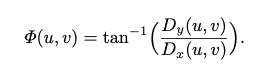

A value near 0° or 180° → edges are mostly horizontal.

A value near ±90° → edges are mostly vertical.

Intermediate values indicate diagonal edges.

In [24]:
def gradient_direction(Gx, Gy):
    """
    Returns gradient direction in degrees from 0 to 360,
    where 0° = right, 90° = up, 180° = left, 270° = down
    """
    Gx = Gx.astype(np.float32)
    Gy = Gy.astype(np.float32)
    angle_rad = np.arctan2(Gy, Gx)
    angle_deg = (np.degrees(angle_rad) + 360) % 360  # wrap to [0, 360)
    return angle_deg.astype(np.float32)

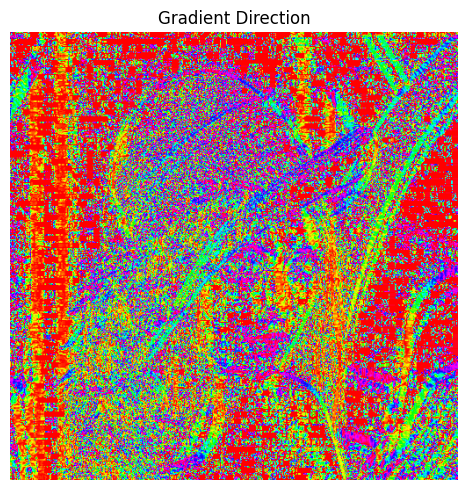

In [25]:
# Apply Sobel filters
sobel_x_result = sobel(gray, filter_x)
sobel_y_result = sobel(gray, filter_y)

# Compute gradient magnitude and direction
Gmag = gradient_magnitude(sobel_x_result, sobel_y_result)
Gdir = gradient_direction(sobel_x_result, sobel_y_result)
Gdir_normalized = Gdir / 360.0

# Plot results
plt.figure(figsize=(20, 5))

plt.title("Gradient Direction")
plt.imshow(Gdir_normalized, cmap='hsv')  # hsv colormap shows angles nicely
plt.axis('off')

plt.tight_layout()
plt.show()


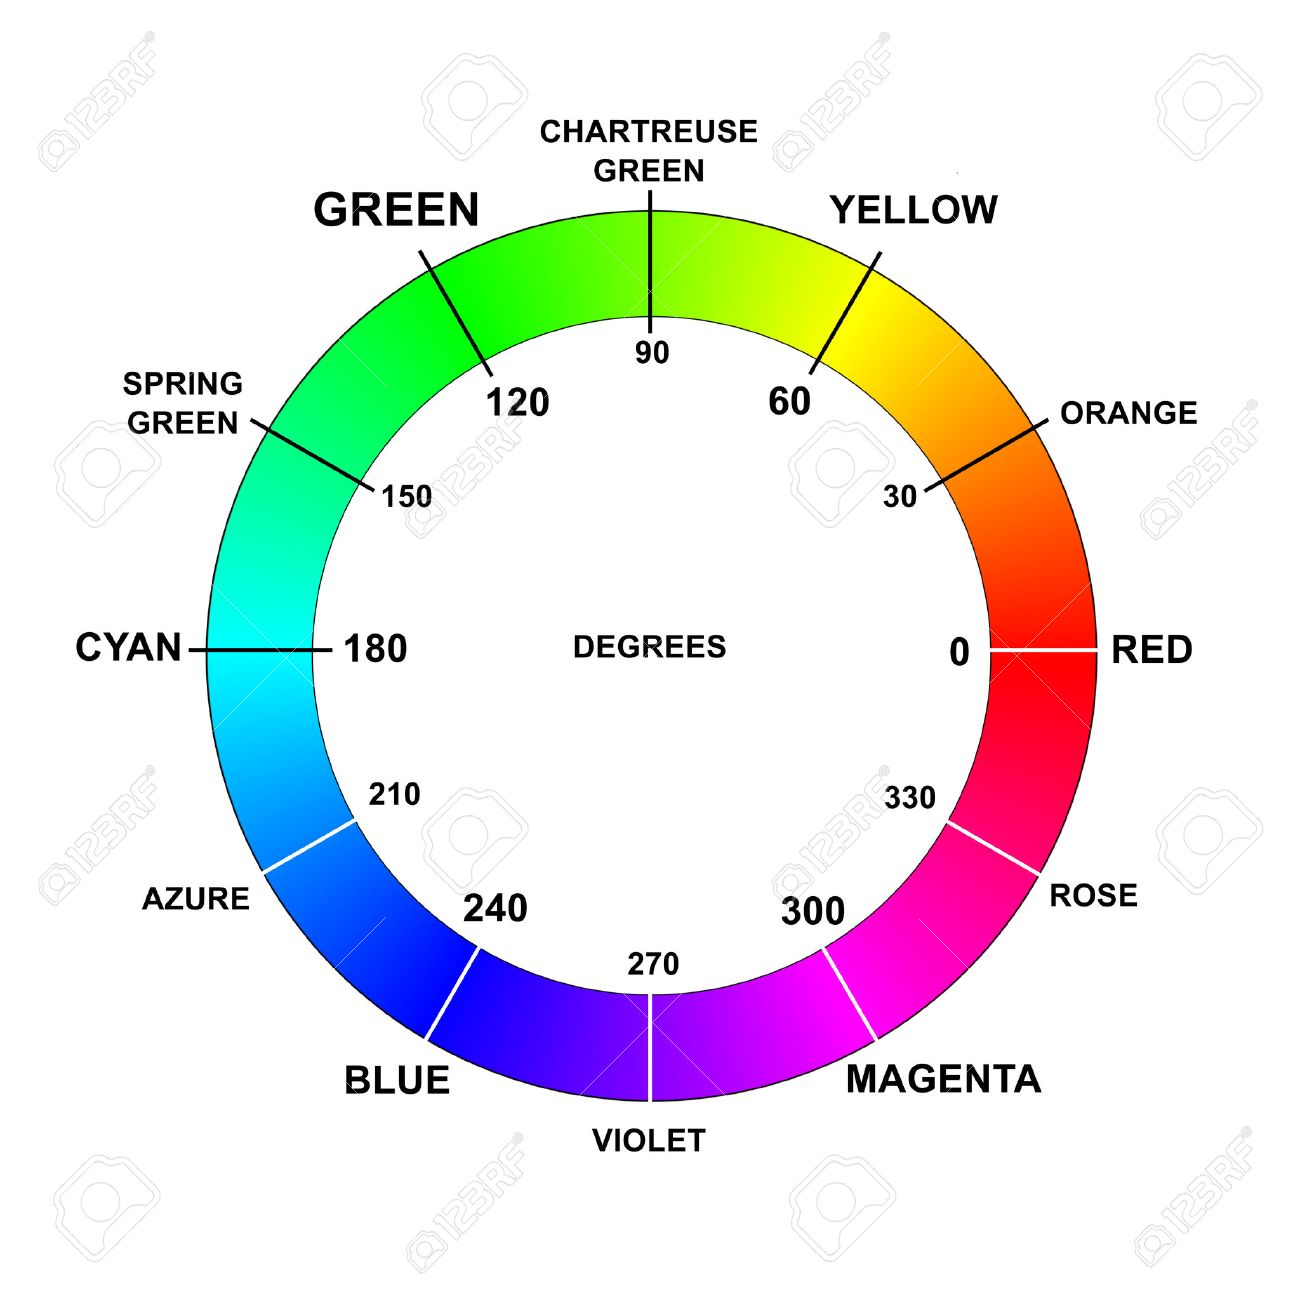

In [26]:
def masked_gradient_direction(Gx, Gy, threshold_ratio=0.2):
    """
    Computes a masked HSV visualization of gradient direction:
    - Edge directions are colored using HSV based on angle (0–360°).
    - Non-edge areas are black.

    Parameters:
        Gx (np.ndarray): Sobel X output.
        Gy (np.ndarray): Sobel Y output.
        threshold_ratio (float): Relative threshold to mask weak gradients (0–1).

    Returns:
        RGB image (H x W x 3) with masked HSV color visualization.
    """
    Gx = Gx.astype(np.float32)
    Gy = Gy.astype(np.float32)

    # Compute gradient magnitude and direction
    magnitude = np.sqrt(Gx**2 + Gy**2)
    direction = np.arctan2(Gy, Gx)  # radians [-π, π]
    direction_deg = (np.degrees(direction) + 360) % 360  # degrees [0, 360)

    # Normalize direction to [0, 1] for HSV hue
    hue = direction_deg / 360.0

    # Create HSV image: hue from direction, saturation=1, value from magnitude
    hsv = np.zeros((*Gx.shape, 3), dtype=np.float32)
    hsv[..., 0] = hue                  # Hue
    hsv[..., 1] = 1.0                  # Saturation
    hsv[..., 2] = 1.0                  # Value initially full

    # Mask: keep only strong gradients
    threshold = threshold_ratio * np.max(magnitude)
    mask = magnitude >= threshold
    hsv[~mask, 2] = 0.0                # Set value to 0 (black) for weak gradients

    # Convert HSV → RGB for display
    rgb = plt.cm.hsv(hsv[..., 0])[:, :, :3] * hsv[..., 2][..., np.newaxis]
    return rgb

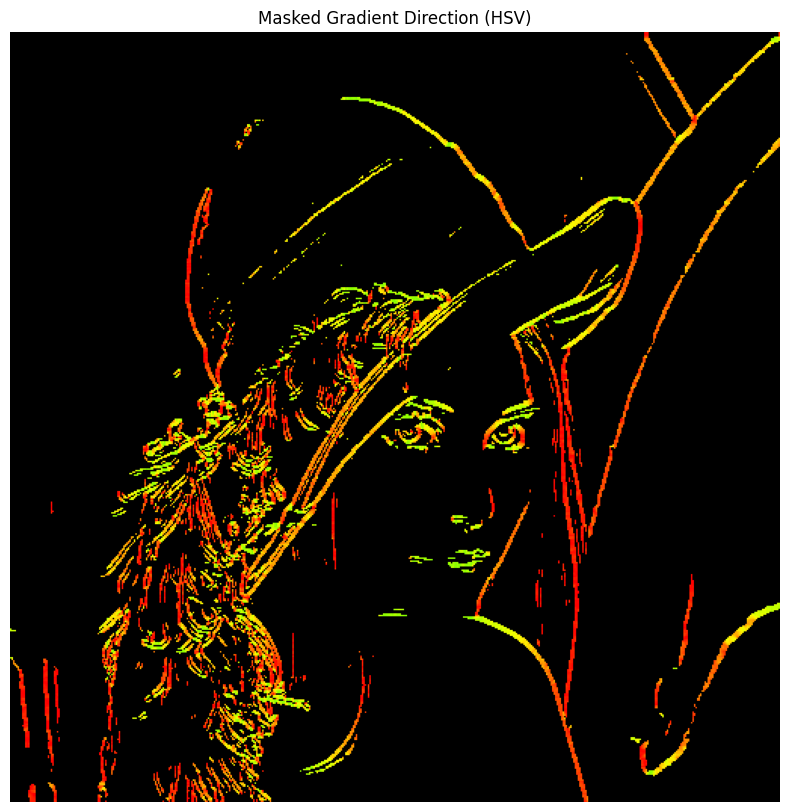

In [27]:
# Compute Sobel outputs
sobel_x_result = sobel(gray, filter_x)
sobel_y_result = sobel(gray, filter_y)

# Get masked gradient direction image
rgb_masked = masked_gradient_direction(sobel_x_result, sobel_y_result, threshold_ratio=0.2)

# Show result
plt.figure(figsize=(10, 10))
plt.title("Masked Gradient Direction (HSV)")
plt.imshow(rgb_masked)
plt.axis('off')
plt.show()


| Hue Color    | Approx. Angle | Edge Orientation (Perpendicular to Gradient) |
| ------------ | ------------- | -------------------------------------------- |
| 🔴 Red       | 0° / 360°     | Vertical edges (left ↔ right transition)     |
| 🟠 Orange    | \~30°         | Slightly diagonal                            |
| 🟡 Yellow    | \~60°         | Diagonal (↘︎↖︎)                              |
| 🟢 Green     | 90°           | Horizontal edges (top ↔ bottom transition)   |
| 🔵 Cyan      | 180°          | Vertical edges (right ↔ left transition)     |
| 🟣 Purple    | \~270°        | Horizontal edges (bottom ↔ top transition)   |
| 🔴 Red again | 360°          | Wraps around to vertical                     |


#### trying it with a 4k image

In [115]:
img = io.imread("4k.jpg")
img_4k = rgb_2_gray(img)

# Sobel X (horizontal edges)
start = time.time()
sobel_x_result = sobel(img_4k, filter_x)
end = time.time()
print("X-direction duration in milliseconds:", (end - start) * 1000)

# Sobel Y (vertical edges)
start = time.time()
sobel_y_result = sobel(img_4k, filter_y)
end = time.time()
print("Y-direction duration in milliseconds:", (end - start) * 1000)

X-direction duration in milliseconds: 161836.58695220947
Y-direction duration in milliseconds: 159690.02199172974


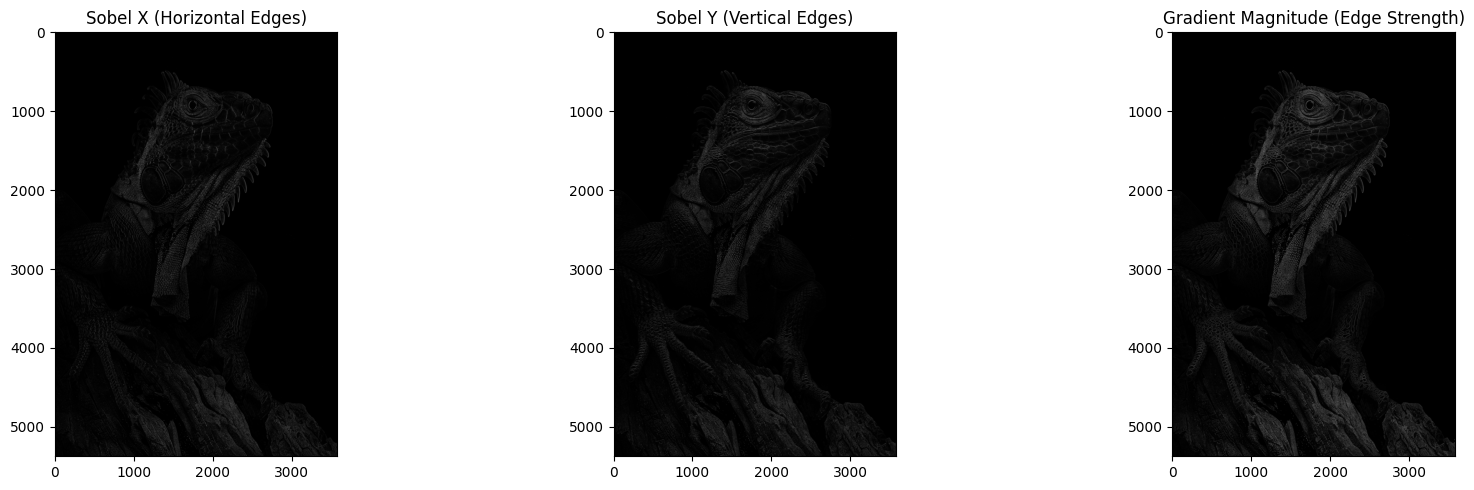

In [116]:
Gx4k = sobel(img_4k, filter_x)
Gy4k = sobel(img_4k, filter_y)
Gmag4k = gradient_magnitude(Gx4k, Gy4k)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.title("Sobel X (Horizontal Edges)")
plt.imshow(sobel_x_result, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Sobel Y (Vertical Edges)")
plt.imshow(sobel_y_result, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Gradient Magnitude (Edge Strength)")
plt.imshow(Gmag4k, cmap='gray')

plt.tight_layout()
plt.show()

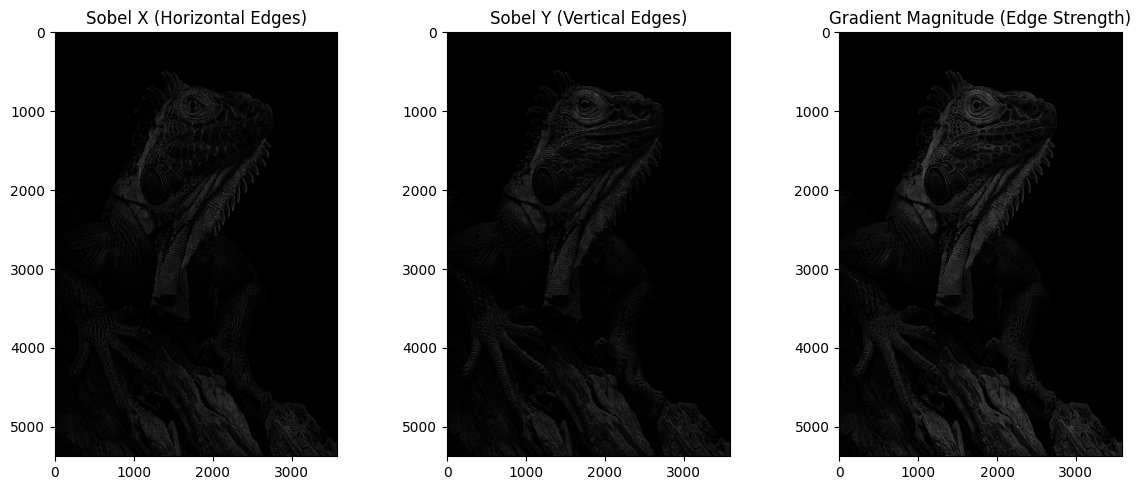

In [120]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.title("Sobel X (Horizontal Edges)")
plt.imshow(sobel_x_result, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Sobel Y (Vertical Edges)")
plt.imshow(sobel_y_result, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Gradient Magnitude (Edge Strength)")
plt.imshow(Gmag4k, cmap='gray')

plt.tight_layout()
plt.show()